In [80]:
import geopandas as gpd
import regionmask
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Precipitation data

In [81]:
ds = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/tp_HMA_1940-2025_ERA5.nc')

In [83]:
ds

<xarray.Dataset> Size: 168MB
Dimensions:  (time: 1032, lat: 101, lon: 201)
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 8kB 1940-01-01T06:00:00 ... 2025-12-01T06:...
  * lat      (lat) float64 808B 45.0 44.75 44.5 44.25 ... 20.75 20.5 20.25 20.0
  * lon      (lon) float64 2kB 60.0 60.25 60.5 60.75 ... 109.2 109.5 109.8 110.0
    expver   (time) <U4 17kB ...
Data variables:
    tp       (time, lat, lon) float64 168MB ...
Attributes:
    units:    mm/month

# Function to select one region from a shapefile with the 22 HIMAP regions

In [84]:
def himap(ds, domain):
    """
        Get the data for the corresponding zone.
        Parameters
        ----------
        domain : str
            Zone name. Options are:
            - Eastern Hindu Kush, Western Himalaya, Eastern Himalaya, 
            Central Himalaya, Karakoram, Western Pamir, Pamir Alay, 
            Northern/Western Tien Shan, Dzhungarsky Alatau, 
            Western Kunlun Shan, Nyainqentanglha, Gangdise Mountains, 
            Hengduan Shan, Tibetan Interior Mountains, Tanggula Shan, 
            Eastern Tibetan Mountains, Qilian Shan, Eastern Kunlun Shan, 
            Altun Shan, Eastern Tien Shan, Central Tien Shan, Eastern Pamir.
        ds : xarray.Dataset (or xarray.DataArray ?) 
        
        Returns
        -------
        ds_region : slice
            Data only in the wanted zone, elsewhere is NaN values.
            A grid cannot be in two different regions. 
            But some of the grids at the limits can be a little bit in the other region just next to the one chosen.
        -------
    """

    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.dims:
        if dim in ['lat', 'latitude','LAT']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LON']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    
    # Shapefile for the different regions
    shp_path = '/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp'
    shp = gpd.read_file(shp_path)

    if shp.crs != "EPSG:4326":
        shp = shp.to_crs("EPSG:4326")

    region = shp[shp["Primary_ID"] == domain]

    # masque précis
    regions = regionmask.Regions(region.geometry.values) # polygone de la région
    mask = regions.mask(ds) # masque NaN ou zéro si dans le masque
    
    ds = ds.where(mask == 0) # mask == 0 créer un masque booléen True/False pour extraire seulement la région voulue

    # découpe la zone pour alléger le dataset
    lonW, latS, lonE, latN = region.total_bounds
    if ds[lat_str][0] > ds[lat_str][-1]:
        lat_slice = slice(latN, latS)  # décroissant
    else:
        lat_slice = slice(latS, latN)  # croissant
    ds_region = ds.sel(
        {lat_str: lat_slice,
         lon_str: slice(lonW, lonE)}
    )
    
    return ds_region

# Function test

## Central Himalaya

In [85]:
ds_dom = himap(ds, 'Central Himalaya')

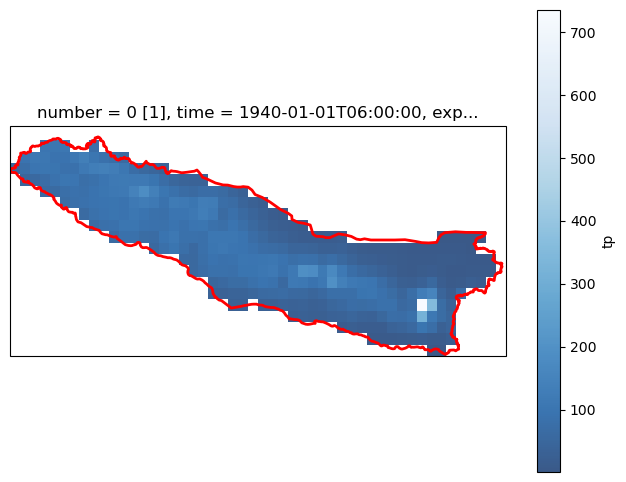

In [89]:
shp_path = '/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp'
shp = gpd.read_file(shp_path)

if shp.crs != "EPSG:4326":
    shp = shp.to_crs("EPSG:4326")

region = shp[shp["Primary_ID"] == "Central Himalaya"]

# prendre un pas de temps pour visualiser
da = ds_dom["tp"].isel(time=0)

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# champ xarray
da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues_r",
    add_colorbar=True, alpha=0.8
)

# contour shapefile
region.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.coastlines()

plt.show()

## Gangdise Mountains (juste above Central Himalaya)

In [90]:
ds_dom = himap(ds, 'Gangdise Mountains')

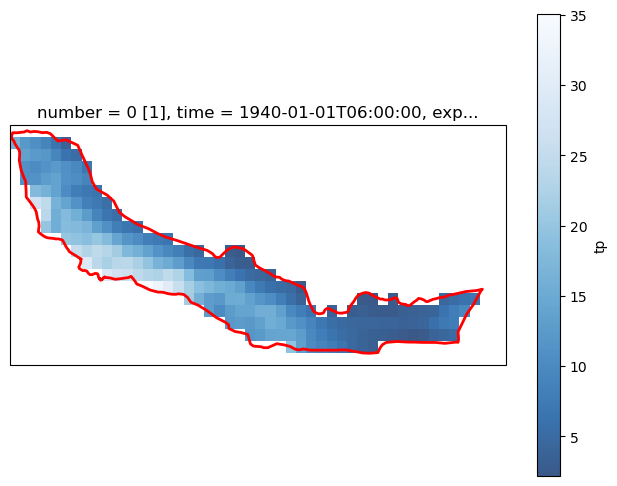

In [92]:
shp_path = '/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp'
shp = gpd.read_file(shp_path)

if shp.crs != "EPSG:4326":
    shp = shp.to_crs("EPSG:4326")

region = shp[shp["Primary_ID"] == "Gangdise Mountains"]

# prendre un pas de temps pour visualiser
da = ds_dom["tp"].isel(time=0)

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# champ xarray
da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues_r",
    add_colorbar=True, alpha=0.8
)

# contour shapefile
region.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.coastlines()

plt.show()